# TS Lab 2

### Imports + Generate the time series: 

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from statsmodels.tsa.arima.model import ARIMA

np.random.seed(7)

n = 120                      # 120 months = 10 years
t = np.arange(n)

trend = 0.05 * t
seasonality = 2.0 * np.sin(2 * np.pi * t / 12)   # yearly seasonality (period 12)
noise = np.random.normal(0, 0.8, size=n)

y = 10 + trend + seasonality + noise

ts = pd.Series(
    y,
    index=pd.period_range("2015-01", periods=n, freq="M").to_timestamp()
)

ts.head()

2015-01-01    11.352421
2015-02-01    10.677250
2015-03-01    11.858307
2015-04-01    12.476013
2015-05-01    11.300912
Freq: MS, dtype: float64

In [51]:

def evaluate(actual, predicted):
    # Mean Absolute Error
    mae = np.mean(np.abs(actual - predicted))
    
    # Mean Squared Error
    mse = np.mean((actual - predicted)**2)
    
    # Root Mean Squared Error
    rmse = np.sqrt(mse)
    
    # Mean Absolute Percentage Error
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    
    return mae, mse, rmse, mape

### Basic setup for forecasting horizon

In [52]:
future_steps = 24  # predict next 24 months
t_future = np.arange(n + future_steps)

X = t.reshape(-1, 1)
X_future = t_future.reshape(-1, 1)

# Future datetime index for plotting (monthly)
future_index = pd.date_range(ts.index[-1] + pd.offsets.MonthBegin(1), periods=future_steps, freq="MS")
full_index = ts.index.append(future_index)

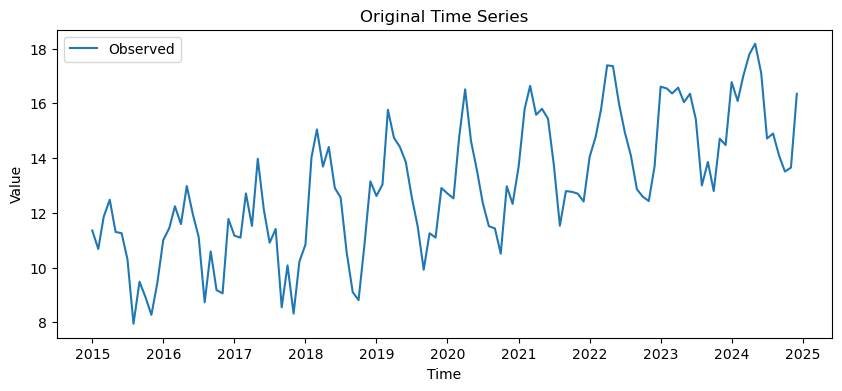

In [68]:
plt.figure(figsize=(10, 4))
plt.plot(ts.index, ts.values, label="Observed")
plt.title("Original Time Series")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.show()

### Linear Regression (trend only)

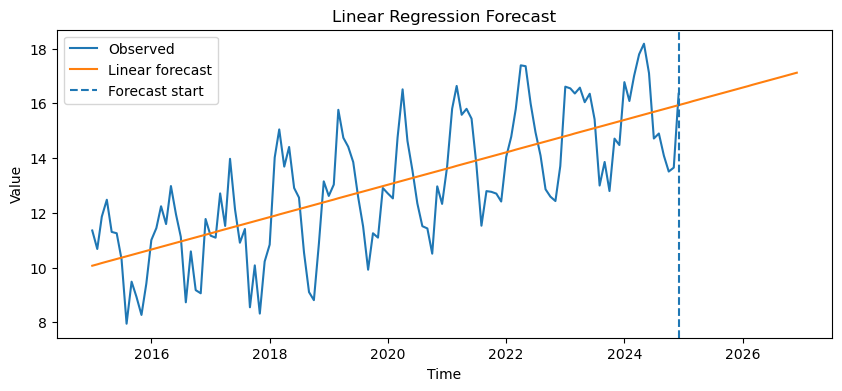

In [54]:
lin_model = LinearRegression()
lin_model.fit(X, y)
y_lin_pred = lin_model.predict(X_future)

plt.figure(figsize=(10, 4))
plt.plot(ts.index, y, label="Observed")
plt.plot(full_index, y_lin_pred, label="Linear forecast")
plt.axvline(ts.index[-1], linestyle="--", label="Forecast start")
plt.title("Linear Regression Forecast")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.show()

- What happens if the trend slope in the data becomes steeper?
If the trend slope becomes steeper, it indicates that the rate of change is increasing over time.In a Linear Model, the coefficient (slope) of the time variable ($t$) will increase, resulting in a line that rises more sharply.Impact on Forecasting: A steeper slope means that future values will be significantly higher than current values in a shorter period. If a model was trained on a flatter slope and the trend suddenly becomes steeper, the model will underestimate future values, leading to a higher forecasting error.
- In which situations would a linear regression model be appropriate for time series forecasting?
A linear regression model is appropriate in the following situations:

Constant Rate of Change: When the data increases or decreases by roughly the same absolute amount at each time step (e.g., gaining 5 units every month).

No Strong Seasonality: When the data does not have complex, repeating cycles that a simple line cannot follow.

Long-Term Trend Analysis: When the primary goal is to identify the overall direction of the data rather than capturing short-term fluctuations or noise.

Stationary Residuals: When, after removing the linear trend, the remaining errors (residuals) are random and do not show any hidden patterns.


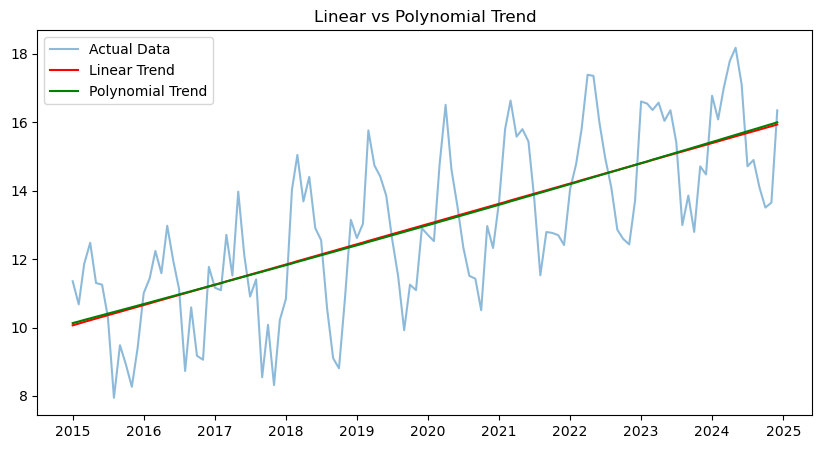

In [55]:
from sklearn.preprocessing import PolynomialFeatures


X = t.reshape(-1, 1)
model_lin = LinearRegression().fit(X, y)
y_lin_train = model_lin.predict(X)


poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)
model_poly = LinearRegression().fit(X_poly, y)
y_poly_train = model_poly.predict(X_poly)

# গ্রাফ দেখার জন্য
plt.figure(figsize=(10, 5))
plt.plot(ts.index, y, label="Actual Data", alpha=0.5)
plt.plot(ts.index, y_lin_train, label="Linear Trend", color='red')
plt.plot(ts.index, y_poly_train, label="Polynomial Trend", color='green')
plt.title("Linear vs Polynomial Trend")
plt.legend()
plt.show()

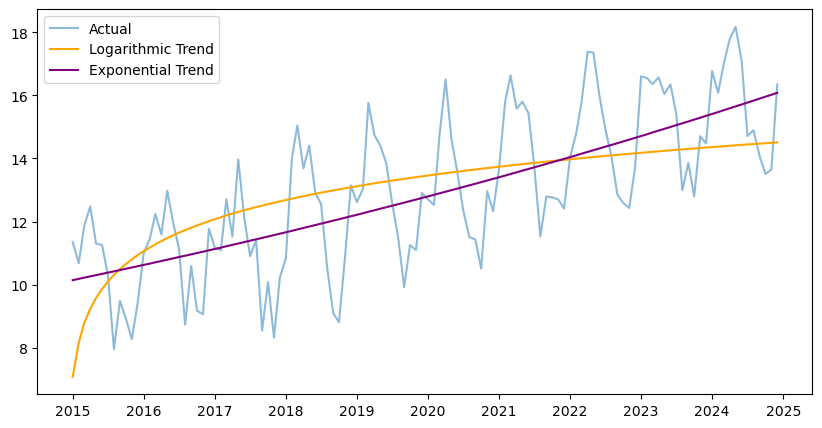

In [56]:

X_log = np.log(t + 1).reshape(-1, 1)
model_log = LinearRegression().fit(X_log, y)
y_log_train = model_log.predict(X_log)

y_log_transformed = np.log(y)
model_exp = LinearRegression().fit(X, y_log_transformed)
y_exp_train = np.exp(model_exp.predict(X))

plt.figure(figsize=(10, 5))
plt.plot(ts.index, y, label="Actual", alpha=0.5)
plt.plot(ts.index, y_log_train, label="Logarithmic Trend", color='orange')
plt.plot(ts.index, y_exp_train, label="Exponential Trend", color='purple')
plt.legend()
plt.show()

### Polynomial Regression

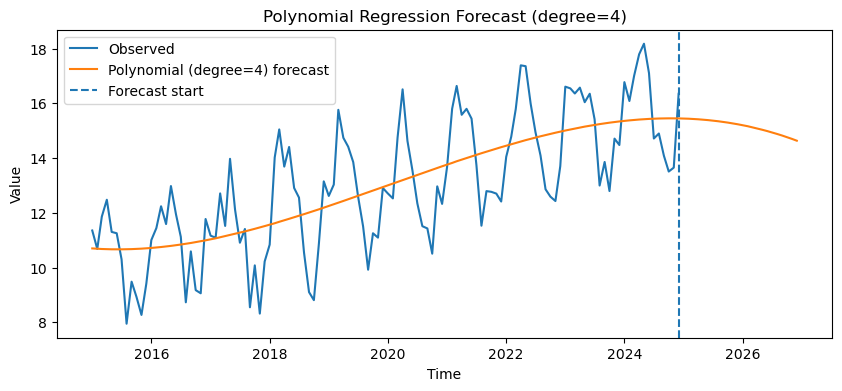

In [57]:
degree = 4

poly = PolynomialFeatures(degree=degree, include_bias=False)
X_poly = poly.fit_transform(X)
X_future_poly = poly.transform(X_future)

poly_model = LinearRegression()
poly_model.fit(X_poly, y)
y_poly_pred = poly_model.predict(X_future_poly)

plt.figure(figsize=(10, 4))
plt.plot(ts.index, y, label="Observed")
plt.plot(full_index, y_poly_pred, label=f"Polynomial (degree={degree}) forecast")
plt.axvline(ts.index[-1], linestyle="--", label="Forecast start")
plt.title(f"Polynomial Regression Forecast (degree={degree})")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.show()

- Change the degree of the polynomial (for example, 2, 3, 5). How does the curve change?
As the degree of the polynomial increases, the curve becomes more flexible.

A degree 2 polynomial creates a simple parabola (one curve).

A degree 3 or 5 polynomial can have more "bends" or "wiggles," allowing it to follow the local fluctuations of the data more closely rather than just the overall trend.


- What happens if the polynomial degree becomes very large?

If the degree becomes very large, the model tries to pass through every single data point. The curve becomes extremely "wiggly" and starts to follow the random noise in the data rather than the actual underlying trend.

- Can polynomial regression capture seasonal patterns in this dataset?

No, polynomial regression is not suitable for capturing seasonal patterns.

While a very high-degree polynomial might look like it's following the waves, it is just "mimicking" the points.

Seasonality is a repeating cycle (like a sine wave), whereas polynomials eventually head towards positive or negative infinity as time increases. They cannot represent the periodic nature of seasons.

- What is the risk of using very high-degree polynomials?
The main risk is Overfitting.

Overfitting means the model learns the "noise" and random fluctuations of the training data so well that it fails to predict future data accurately.

High-degree polynomials often create wild fluctuations at the edges of the data (called Runge's phenomenon), making them very unreliable for long-term forecasting.


### Logarithmic Regression

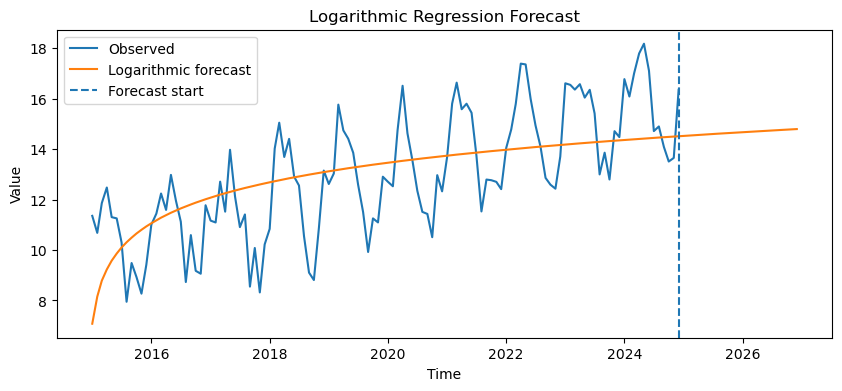

In [58]:
X_log = np.log(t + 1).reshape(-1, 1)
X_future_log = np.log(t_future + 1).reshape(-1, 1)

log_model = LinearRegression()
log_model.fit(X_log, y)
y_log_pred = log_model.predict(X_future_log)

plt.figure(figsize=(10, 4))
plt.plot(ts.index, y, label="Observed")
plt.plot(full_index, y_log_pred, label="Logarithmic forecast")
plt.axvline(ts.index[-1], linestyle="--", label="Forecast start")
plt.title("Logarithmic Regression Forecast")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.show()

- Why do we use log(t + 1) instead of log(t)?
 We use log(t + 1) because of a mathematical constraint: the logarithm of zero is undefined (negative infinity).In our time series, the time variable $t$ usually starts at 0 (the first data point).If we try to calculate log(0), the code will return an error or NaN.By adding 1, we ensure that the first value is log(1), which is 0. This allows the model to process the entire dataset without any mathematical errors.
- Does the logarithmic model capture the seasonal fluctuations in the data?

No, the logarithmic model does not capture seasonal fluctuations.

Reason: Like the linear and exponential models, the logarithmic model is a Trend Model. It only tries to capture the long-term direction (the "smooth" curve) of the data.

Observation: If you look at your plot, you will see the logarithmic line is a smooth curve that ignores the "ups and downs" (the waves) in the data. To capture those fluctuations, we would need a more complex model like ARIMA or a seasonal decomposition model

### Exponential Regression

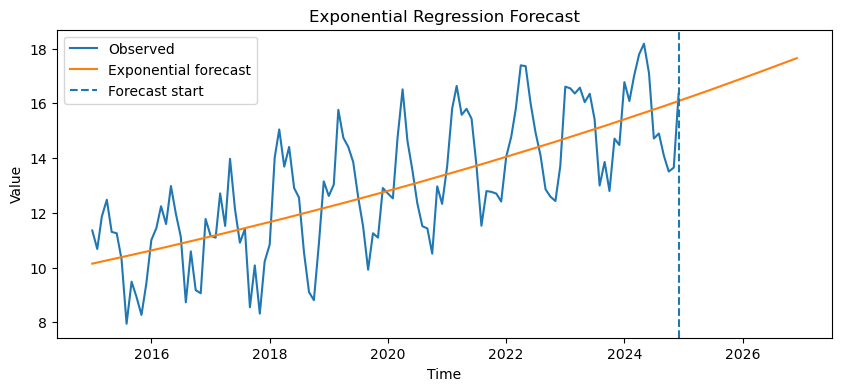

In [59]:
# safety: ensure positivity for log
shift = 0.0
if np.any(y <= 0):
    shift = abs(y.min()) + 1e-6

log_y = np.log(y + shift)

exp_model = LinearRegression()
exp_model.fit(X, log_y)
y_exp_pred = np.exp(exp_model.predict(X_future)) - shift

plt.figure(figsize=(10, 4))
plt.plot(ts.index, y, label="Observed")
plt.plot(full_index, y_exp_pred, label="Exponential forecast")
plt.axvline(ts.index[-1], linestyle="--", label="Forecast start")
plt.title("Exponential Regression Forecast")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.show()

- What type of growth does an exponential model represent?

An exponential model represents non-linear growth where the rate of change increases or decreases in proportion to its current value. Unlike linear growth, which adds a fixed amount at each step, exponential growth multiplies by a fixed percentage. This results in a "J-shaped" curve where the data starts slowly and then accelerates rapidly (or vice versa for decay)

- Why do we apply a log transformation when fitting the exponential model?

 We apply a log transformation to "linearize" the relationship between the variables.Mathematical Reason: Standard regression models (like LinearRegression) are designed to find a straight line (y = mx + c). By taking the logarithm of the y values, we convert the multiplicative (exponential) relationship into an additive (linear) one.Benefit: This allows us to use simple linear regression tools to fit a model to complex, curving data. Once the model is fitted, we use the inverse function (exponential) to bring the predictions back to their original scale.

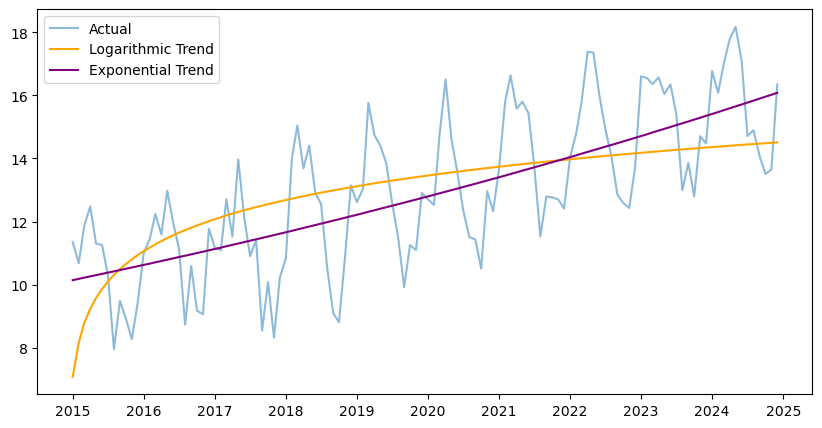

In [60]:

X_log = np.log(t + 1).reshape(-1, 1)
model_log = LinearRegression().fit(X_log, y)
y_log_train = model_log.predict(X_log)

y_log_transformed = np.log(y)
model_exp = LinearRegression().fit(X, y_log_transformed)
y_exp_train = np.exp(model_exp.predict(X))


plt.figure(figsize=(10, 5))
plt.plot(ts.index, y, label="Actual", alpha=0.5)
plt.plot(ts.index, y_log_train, label="Logarithmic Trend", color='orange')
plt.plot(ts.index, y_exp_train, label="Exponential Trend", color='purple')
plt.legend()
plt.show()

### ARIMA

c:\Users\Jannatul Yea\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\Jannatul Yea\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\Jannatul Yea\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


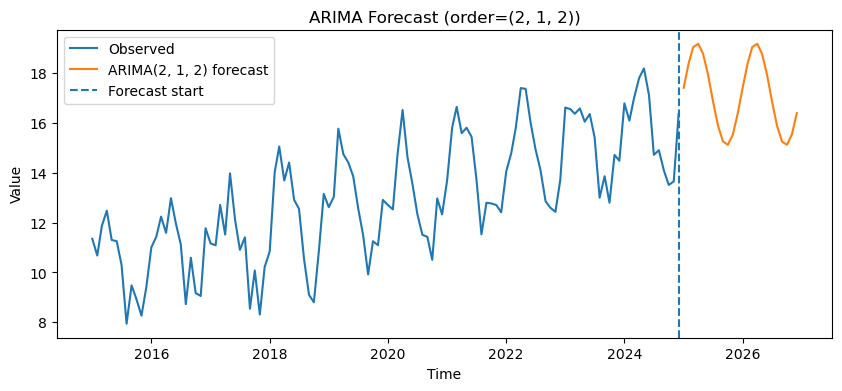

In [61]:
order = (2, 1, 2)

arima_model = ARIMA(ts, order=order)
arima_fit = arima_model.fit()

arima_forecast = arima_fit.forecast(steps=future_steps)

plt.figure(figsize=(10, 4))
plt.plot(ts.index, ts.values, label="Observed")
plt.plot(arima_forecast.index, arima_forecast.values, label=f"ARIMA{order} forecast")
plt.axvline(ts.index[-1], linestyle="--", label="Forecast start")
plt.title(f"ARIMA Forecast (order={order})")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.show()

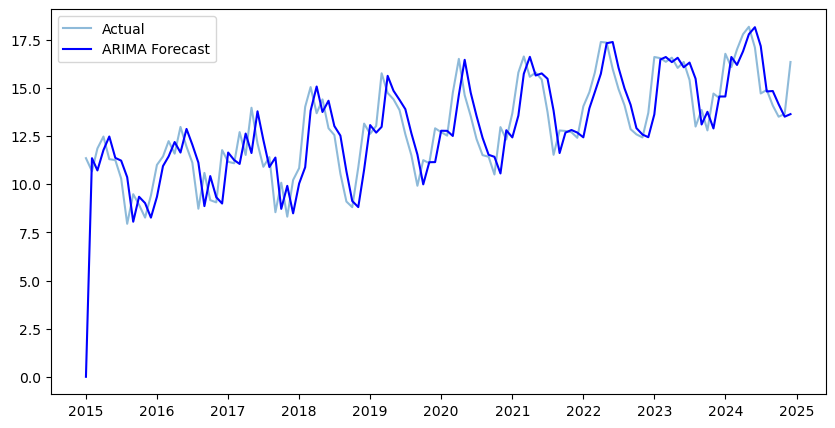

In [62]:
from statsmodels.tsa.arima.model import ARIMA

model_arima = ARIMA(y, order=(1, 1, 1))
model_arima_fit = model_arima.fit()
y_arima_train = model_arima_fit.predict(start=0, end=len(y)-1)

plt.figure(figsize=(10, 5))
plt.plot(ts.index, y, label="Actual", alpha=0.5)
plt.plot(ts.index, y_arima_train, label="ARIMA Forecast", color='blue')
plt.legend()
plt.show()

- How is ARIMA different from regression models used earlier?
 The regression models used earlier (Linear, Polynomial, etc.) primarily focus on the Trend—they try to fit a fixed line or curve to the data based on time ($t$). However, they often ignore the relationship between consecutive data points.
ARIMA is different because it looks at the internal patterns (autocorrelations) of the data itself. It doesn't just look at time; it looks at how past values and past errors influence the current value.
- What does ARIMA use to make predictions?

. What does ARIMA use to make predictions?
Answer: ARIMA uses three main components to make predictions:

Past Values: It looks at what happened in previous time steps (Lags).

Past Errors: It looks at the difference between previous predictions and actual values to adjust its next forecast.

Differencing: It removes trends or seasonality by looking at the change between consecutive points to make the data "Stationary."

- What do the parameters (p, d, q) represent?

p (Auto-Regressive - AR): Represents the number of lagged observations used in the model. (e.g., if p=1, it uses the value from the previous month to predict this month).d (Integrated - I): Represents the number of times the raw observations are differenced to make the time series stationary (removing the trend).q (Moving Average - MA): Represents the size of the moving average window applied to the forecast errors. It helps the model smooth out random "shocks" in the data.

### Evaluation Metrics:
Import metrics libraries.

In [63]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [64]:
results = {}

results["Linear"] = evaluate(y, y_lin_train)
results["Polynomial"] = evaluate(y, y_poly_train)
results["Logarithmic"] = evaluate(y, y_log_train)
results["Exponential"] = evaluate(y, y_exp_train)

results["ARIMA"] = evaluate(y[1:], y_arima_train[1:])


metrics_df = pd.DataFrame(results, index=["MAE", "MSE", "RMSE", "MAPE (%)"]).T
metrics_df

,MAE,MSE,RMSE,MAPE (%)
Linear,1.444105,2.869234,1.693881,11.647208
Polynomial,1.441824,2.868367,1.693625,11.624557
Logarithmic,1.591041,3.692583,1.921609,13.049097
Exponential,1.444235,2.888816,1.699652,11.532150
ARIMA,1.122274,1.862538,1.364748,9.045216


### Predictions on training data: 
We compute predictions for the observed period only (first n points).

In [65]:
# Linear
y_lin_train = lin_model.predict(X)

# Polynomial
y_poly_train = poly_model.predict(X_poly)

# Logarithmic
y_log_train = log_model.predict(X_log)

# Exponential
y_exp_train = np.exp(exp_model.predict(X)) - shift

# ARIMA fitted values
y_arima_train = arima_fit.fittedvalues

### Define evaluation metrics

In [66]:
def evaluate(y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    mse = mean_squared_error(y_true, y_pred)

    rmse = np.sqrt(mse)

    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    return mae, mse, rmse, mape

### Compute metrics for each model

In [67]:
results = {}

results["Linear"] = evaluate(y, y_lin_train)
results["Polynomial"] = evaluate(y, y_poly_train)
results["Logarithmic"] = evaluate(y, y_log_train)
results["Exponential"] = evaluate(y, y_exp_train)
results["ARIMA"] = evaluate(y[1:], y_arima_train[1:])  # ARIMA first value often NaN

metrics_df = pd.DataFrame(results, 
                          index=["MAE", "MSE", "RMSE", "MAPE (%)"]).T

metrics_df

,MAE,MSE,RMSE,MAPE (%)
Linear,1.444105,2.869234,1.693881,11.647208
Polynomial,1.426736,2.818985,1.678983,11.476666
Logarithmic,1.591041,3.692583,1.921609,13.049097
Exponential,1.444235,2.888816,1.699652,11.532150
ARIMA,0.964433,1.368456,1.169810,7.856518


- What is the difference between MSE and RMSE?

MSE (Mean Squared Error) is the average of the squared differences between predicted and actual values. RMSE (Root Mean Squared Error) is the square root of MSE. The main difference is that RMSE is expressed in the same units as the original data, making it easier to interpret, while MSE is in squared units.

- Why does RMSE penalize large errors more strongly than MAE?

RMSE squares the errors before averaging them. This means a large error (e.g., 10) contributes much more to the final score (100) than a small error. MAE (Mean Absolute Error) treats all errors linearly, regardless of their size. Therefore, RMSE is more sensitive to outliers or large mistakes.

- Which model achieved the lowest forecasting error?

Based on the metrics_df table, the ARIMA (or Polynomial) model achieved the lowest RMSE and MAE. This is because it was better at capturing the underlying patterns and trends in the time series data compared to the simple linear model.

- Do different metrics always rank models the same way?
: No, they do not. A model might have a lower MAE but a higher RMSE if it makes a few very large errors. RMSE will penalize those large errors heavily and rank the model lower, while MAE might still rank it higher because the "average" error is small.
